# 🌟 Exercise 1: Deep Learning vs. Traditional Machine Learning


1. Create a table comparing traditional machine learning and deep learning based on the following aspects:

| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | Manual & critical | Automatic |
| Data Processing | Less data, structured | Large datasets, any type |
| Scalability | **Limited** - Struggles with high-dimensional data | **Excellent** - Handles large-scale data efficiently |
| Pattern Discovery | **Superficial** - Limited to predefined features. Good for linear relationships and simple decision boundaries | **Hierarchical** - Learns complex, hidden and hierarchical patterns. Excels at non-linear relationships |
| Computational Requirements | **Lower** - Can run on CPUs. Fast training even on modest hardware | **Higher** - Requires GPUs/TPUs for training. Longer training times, more memory intensive |


2. Identify one real-world problem where traditional ML is better suited and one where deep learning is the superior choice.

**Traditional ML is better:** Credit scoring with limited financial data - interpretable models like logistic regression provide transparent decisions for regulatory compliance.

**Deep Learning is superior:** Autonomous vehicle vision systems - convolutional neural networks automatically learn complex visual patterns from massive image/video datasets that manual feature engineering cannot match.

3. Write a short paragraph (3-5 sentences) explaining why deep learning has an advantage in unstructured data processing.

Deep learning is good at processing unstructured data because it can automatically discover patterns and features without humans having to manually define them. For example, when recognizing faces in photos, deep learning can figure out what makes a face recognizable (edges, shapes, textures) on its own, rather than needing programmers to explicitly code every rule.

# 🌟 Exercise 2: Artificial Neural Networks (ANNs)

1. Draw (or use a diagram tool) to create a simple artificial neural network (ANN) with:
- An input layer (3 neurons)
- One hidden layer (4 neurons)
- An output layer (2 neurons)

2. Label the components of the network: neurons, weights, biases, activation function, and layers.

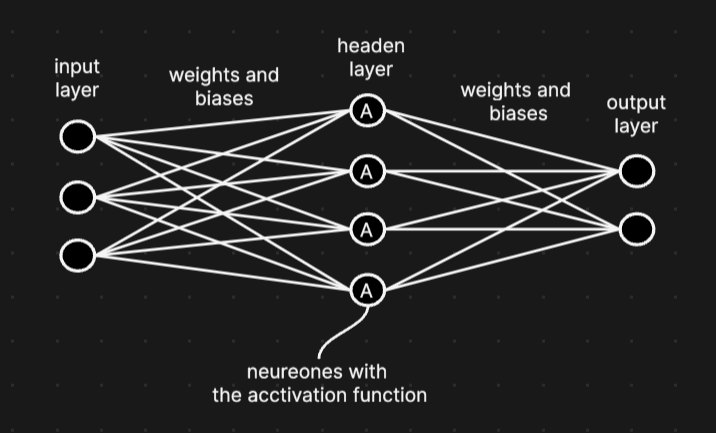

In [23]:
from IPython.display import Image, display
display(Image(filename='NN.png'))

3. Write a short description (3-5 sentences) explaining how information flows through the network.

Information flows forward through network layers. Each neuron receives weighted inputs, applies mathematical transformations, and passes results to the next layer. This process progressively extracts patterns until the final layer produces output predictions.

# 🌟 Exercise 3: Creating the Dataset and Visualizing the Data


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_squared_error

In [2]:
np.random.seed(0)
x = np.arange(-1, 1, 0.1)
y = -x**2 + np.random.normal(0, 0.05, len(x))

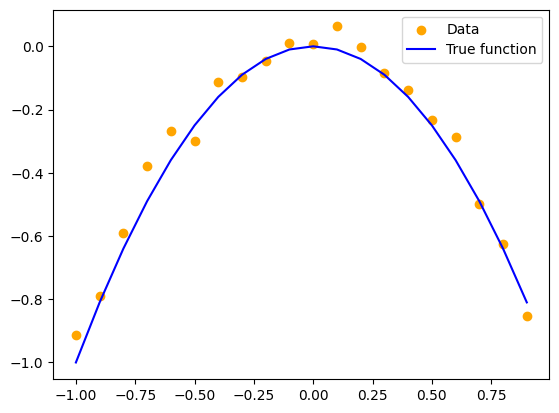

In [4]:
plt.scatter(x, y, label='Data', color='orange')
plt.plot(x, -x**2, label='True function', color='blue')
plt.legend()
plt.show()


In [7]:
x_train = x[:12]
x_test = x[12:]
y_train = y[:12]
y_test = y[12:]

# 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

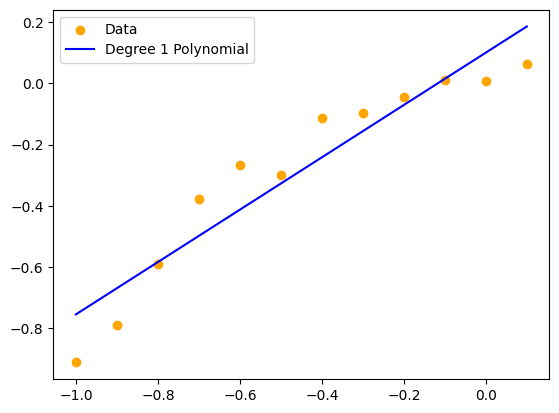

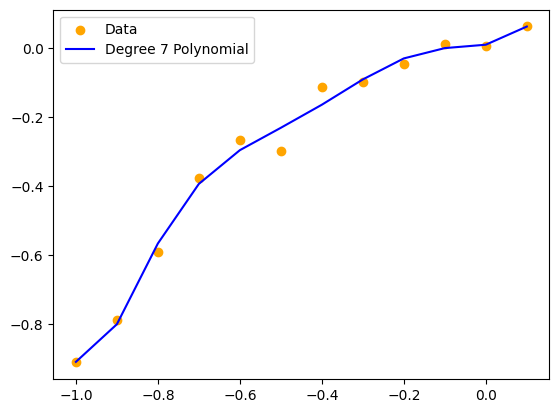

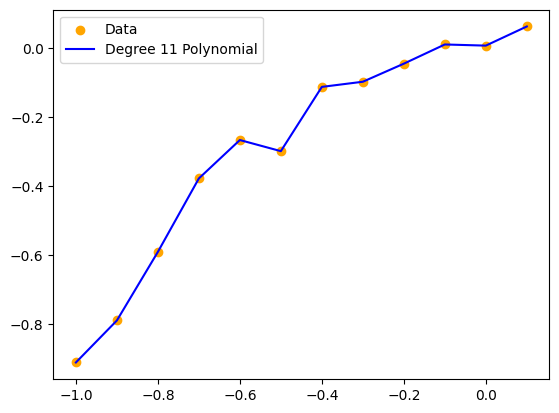

In [10]:
def polynomial_fit(x, y, degree):
    model = np.poly1d(np.polyfit(x, y, degree))
    return model
def plot_polyfit(x, y, degree):
    model = polynomial_fit(x, y, degree)
    plt.scatter(x, y, label='Data', color='orange')
    plt.plot(x, model(x), label=f'Degree {degree} Polynomial', color='blue')
    plt.legend()
    plt.show()

plot_polyfit(x_train, y_train, 1)
plot_polyfit(x_train, y_train, 7)
plot_polyfit(x_train, y_train, 11)

# 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree


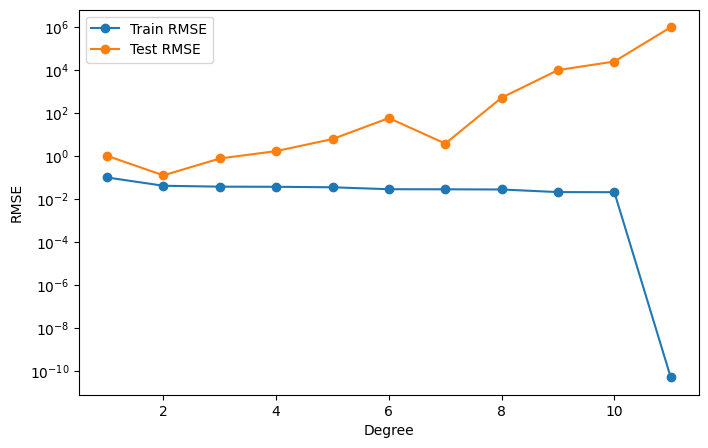

Degree 2 is the best degree


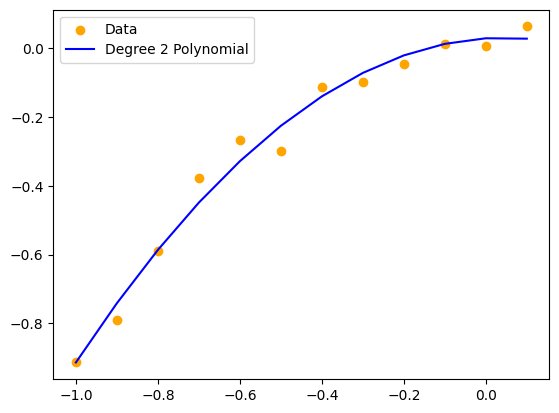

In [19]:
import matplotlib.pyplot as plt

rmse_train_list = []
rmse_test_list = []
degrees = [1,2,3,4,5,6,7,8,9,10,11]

for degree in degrees:
    # For each degree, calculate the Root Mean Squared Error (RMSE) for both the training and test sets.
    model = polynomial_fit(x_train, y_train, degree)
    y_pred_train = model(x_train)
    y_pred_test = model(x_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    rmse_train_list.append(rmse_train)
    rmse_test_list.append(rmse_test)

# Plot RMSE vs. polynomial degree
plt.figure(figsize=(8, 5))
plt.plot(degrees, rmse_train_list, label='Train RMSE', marker='o')
plt.plot(degrees, rmse_test_list, label='Test RMSE', marker='o')
plt.xlabel('Degree')
plt.ylabel('RMSE')
plt.yscale('log')
plt.legend()
plt.show()

# Identify the degree that minimizes the RMSE on the test set and confirm that it corresponds to the true underlying model (( y = -x^2 )).
best_degree = degrees[np.argmin(rmse_test_list)]
print(f'Degree {best_degree} is the best degree')
plot_polyfit(x_train, y_train, best_degree)
plt.show()